# 07 — Volatilité implicite vs réalisée : prime de risque de volatilité et régimes de marché en 2022

**Questions.**
1. La volatilité implicite diffère-t-elle systématiquement de la volatilité réalisée ensuite ? (*volatility risk premium*, VRP)
2. Comment le niveau, le skew et la VRP évoluent-ils selon le régime de marché ?

On construit pour **chaque jour de 2022** (247 séances) :
- $\sigma^{imp}_{30j}$ : IV ATM forward à maturité constante 30 jours (interpolée en variance totale entre les deux échéances encadrantes) — un équivalent « maison » du VIX sans le skew ;
- le **skew 30 jours** : $\sigma(K = 90\%F) - \sigma(K = 100\%F)$ ;
- la **vol réalisée** : $\sigma^{réal} = \sqrt{252}\;\text{std}(\ln S_t/S_{t-1})$ sur 21 séances, passée (*backward*) et future (*forward*, ce que l'IV 30 j est censée anticiper).

$$\text{VRP}_t = \sigma^{imp}_{30j}(t) - \sigma^{réal}_{t \to t+21}$$

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
import time
from market_data import get_option_chain, get_underlying_history
from data_cleaning import clean_option_chain
from implied_vol import add_implied_dividend, add_implied_volatility
from pipeline import otm_mask, R_DEFAULT
from surface_tools import otm_slices, iv_at
r = R_DEFAULT

## 1. Construction des séries quotidiennes

In [2]:
t0 = time.perf_counter()
chain, _ = clean_option_chain(get_option_chain(quote_date="all"))
chain = chain[chain["T"].between(5 / 365, 100 / 365) & (chain.strike / chain.spot).between(0.80, 1.10)]
chain = add_implied_dividend(chain, r)

# pour chaque date : les deux échéances qui encadrent 30 jours
exps = chain.groupby(["quote_date", "expiration"])["T"].first().reset_index()
keep = []
for d, g in exps.groupby("quote_date"):
    lo, hi = g[g["T"] <= 30 / 365], g[g["T"] >= 30 / 365]
    if len(lo) and len(hi):
        keep += [(d, lo.loc[lo["T"].idxmax(), "expiration"]), (d, hi.loc[hi["T"].idxmin(), "expiration"])]
keep = pd.DataFrame(keep, columns=["quote_date", "expiration"]).drop_duplicates()
sub = chain.merge(keep, on=["quote_date", "expiration"])
sub = sub[otm_mask(sub)]
sub = add_implied_volatility(sub, r=r, q="q_implied")
sub["is_otm"] = True
print(f"{len(sub):,} options OTM inversées sur {sub.quote_date.nunique()} dates en {time.perf_counter()-t0:.0f} s "
      f"({(sub.iv_status=='success').mean():.1%} de succès)")

32,848 options OTM inversées sur 247 dates en 123 s (100.0% de succès)


In [3]:
rows = []
for d, g in sub.groupby("quote_date"):
    sl = otm_slices(g)
    atm = iv_at(sl, 0.0, 30 / 365)
    rows.append({"date": d, "iv30": atm, "iv30_90": iv_at(sl, np.log(0.90), 30 / 365), "iv30_105": iv_at(sl, np.log(1.05), 30 / 365)})
ts = pd.DataFrame(rows).set_index("date").sort_index()
spot = get_underlying_history()
ts = ts.join(spot, how="inner")
ret = np.log(spot).diff()
ts["ret"] = ret
ts["rv_back"] = ret.rolling(21).std().reindex(ts.index) * np.sqrt(252)
ts["rv_fwd"] = ret[::-1].rolling(21).std()[::-1].shift(-1).reindex(ts.index) * np.sqrt(252)
ts["skew30"] = ts.iv30_90 - ts.iv30
ts["vrp"] = ts.iv30 - ts.rv_fwd
ts["drawdown"] = ts.spot / ts.spot.cummax() - 1
print(f"Vol réalisée sur l'année 2022 : {ret.std()*np.sqrt(252):.1%} | IV 30 j moyenne : {ts.iv30.mean():.1%}")
ts.describe().T[["mean", "std", "min", "max"]]

Vol réalisée sur l'année 2022 : 24.3% | IV 30 j moyenne : 22.8%


,mean,std,min,max
iv30,0.2284,0.0398,0.1232,0.3098
iv30_90,0.2994,0.0348,0.2352,0.3903
iv30_105,0.1936,0.0415,0.0995,0.2858
spot,409.3138,29.0563,356.5800,477.7700
ret,-0.0009,0.0153,-0.0443,0.0534
rv_back,0.2446,0.0463,0.1595,0.3508
rv_fwd,0.2446,0.0463,0.1595,0.3508
skew30,0.0724,0.0205,0.0277,0.1169
vrp,-0.0141,0.0534,-0.1623,0.1080
drawdown,-0.1433,0.0608,-0.2537,0.0000


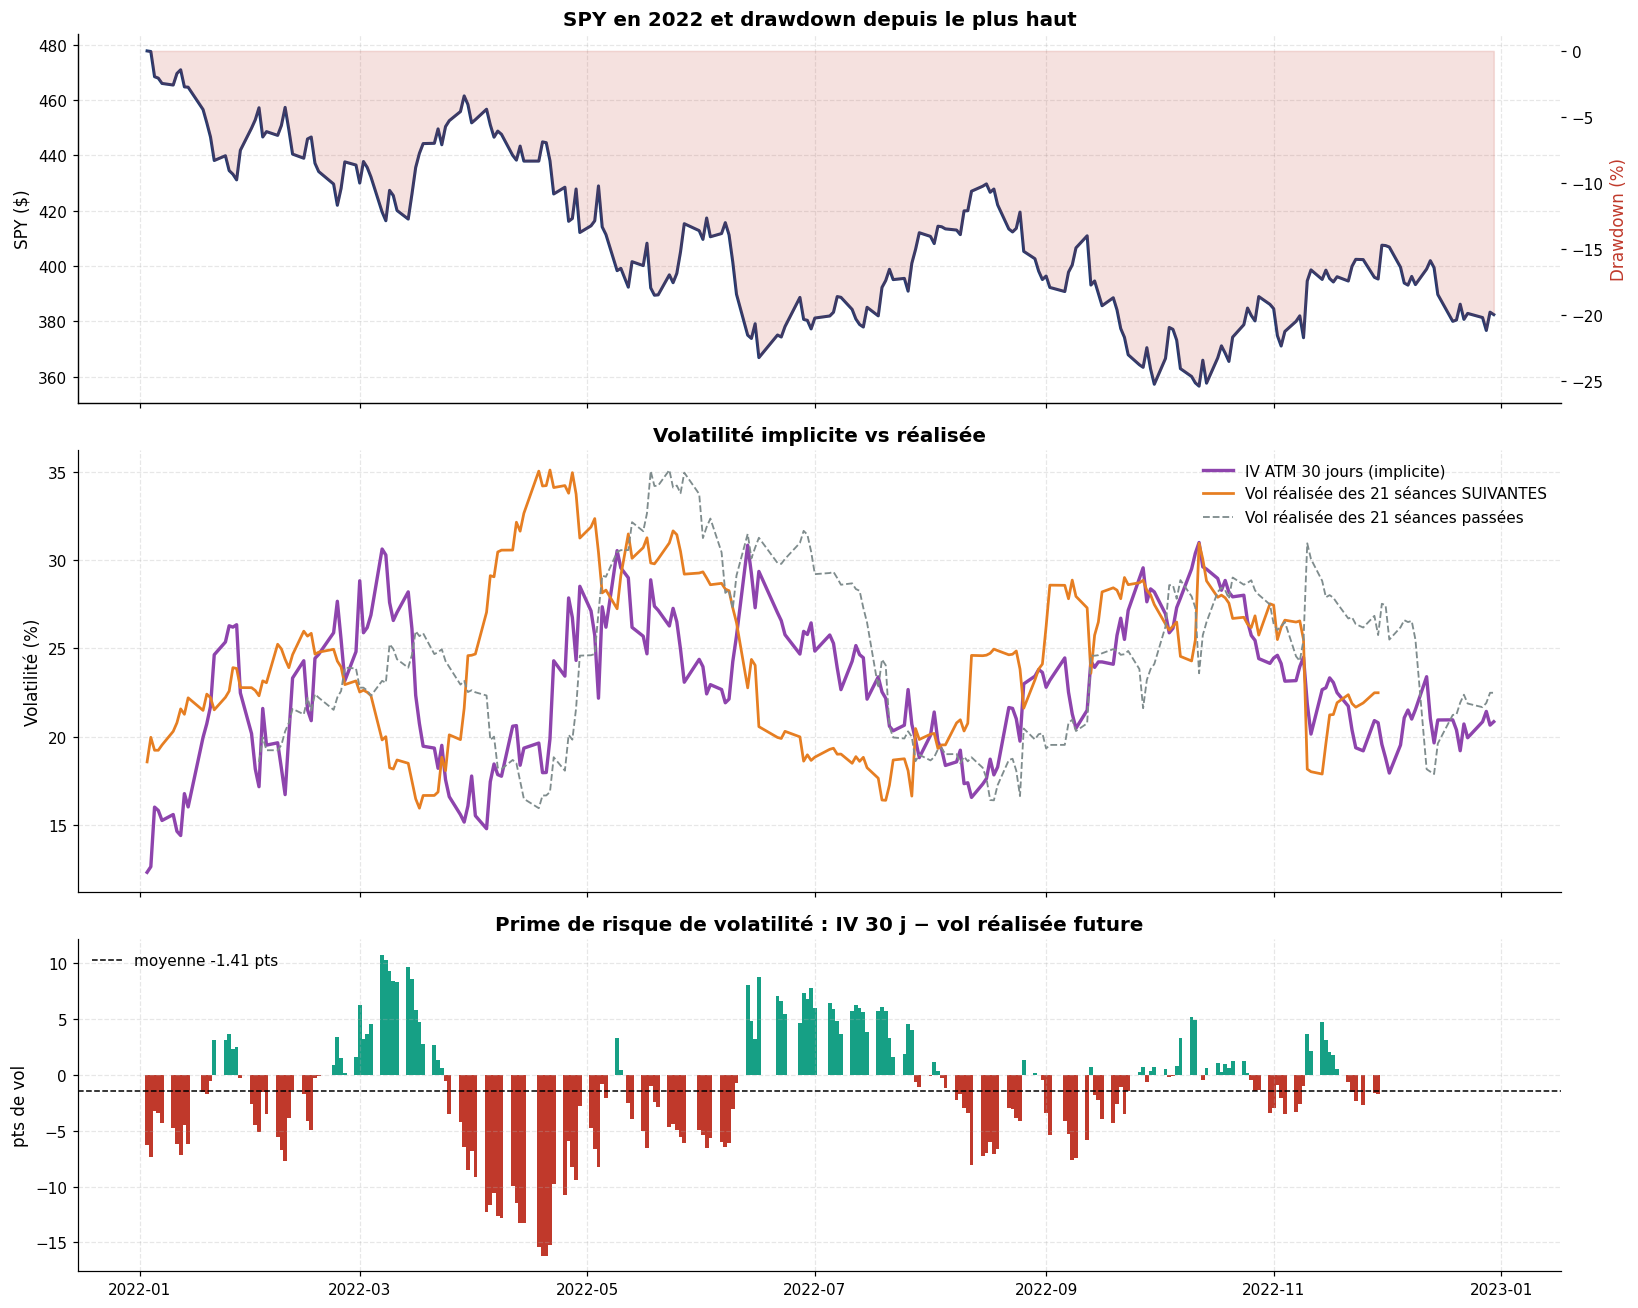

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={"height_ratios": [1, 1.2, 0.9]})
axes[0].plot(ts.index, ts.spot, color=PALETTE["navy"], lw=2); axes[0].set_ylabel("SPY ($)")
ax0b = axes[0].twinx(); ax0b.fill_between(ts.index, ts.drawdown * 100, 0, color=PALETTE["crimson"], alpha=0.15); ax0b.set_ylabel("Drawdown (%)", color=PALETTE["crimson"]); ax0b.grid(False)
axes[0].set_title("SPY en 2022 et drawdown depuis le plus haut")
axes[1].plot(ts.index, ts.iv30 * 100, color=PALETTE["purple"], lw=2.2, label="IV ATM 30 jours (implicite)")
axes[1].plot(ts.index, ts.rv_fwd * 100, color=PALETTE["orange"], lw=1.8, label="Vol réalisée des 21 séances SUIVANTES")
axes[1].plot(ts.index, ts.rv_back * 100, color=PALETTE["grey"], lw=1.2, ls="--", label="Vol réalisée des 21 séances passées")
axes[1].set_ylabel("Volatilité (%)"); axes[1].legend(); axes[1].set_title("Volatilité implicite vs réalisée")
v = ts.vrp * 100
axes[2].bar(ts.index, v, color=np.where(v > 0, PALETTE["teal"], PALETTE["crimson"]), width=1.0)
axes[2].axhline(v.mean(), color="k", ls="--", lw=1, label=f"moyenne {v.mean():+.2f} pts")
axes[2].set_ylabel("pts de vol"); axes[2].legend(); axes[2].set_title("Prime de risque de volatilité : IV 30 j − vol réalisée future")
fig.tight_layout(); savefig(fig, "07_iv_vs_realized_vrp.png"); plt.show()

In [5]:
valid = ts.dropna(subset=["vrp"])
vrp_stats = pd.DataFrame({
    "Indicateur": ["IV 30 j moyenne (%)", "Vol réalisée future moyenne (%)", "VRP moyenne (pts)", "VRP médiane (pts)",
                   "% de jours où IV > RV future", "Corrélation IV / RV future", "Corrélation RV passée / RV future"],
    "Valeur": [100 * valid.iv30.mean(), 100 * valid.rv_fwd.mean(), 100 * valid.vrp.mean(), 100 * valid.vrp.median(),
               100 * (valid.vrp > 0).mean(), valid.iv30.corr(valid.rv_fwd), valid.rv_back.corr(valid.rv_fwd)]})
save_table(vrp_stats, "07_vrp_stats", floatfmt=".2f"); vrp_stats

,Indicateur,Valeur
0,IV 30 j moyenne (%),23.0570
1,Vol réalisée future moyenne (%),24.4647
2,VRP moyenne (pts),-1.4077
3,VRP médiane (pts),-1.3241
4,% de jours où IV > RV future,38.9381
5,Corrélation IV / RV future,0.2524
6,Corrélation RV passée / RV future,-0.0196


**Lecture.** Sur longue période, l'IV des indices dépasse la vol réalisée en moyenne de plusieurs points : c'est la prime que les vendeurs d'options exigent pour porter le risque de krach. **2022 est une année atypique** : la VRP moyenne est **négative (−1,4 pt)** et l'IV n'a dépassé la vol réalisée future que **39 % des jours** — une mauvaise année pour les vendeurs de volatilité (ce qu'illustre le backtest du notebook 06).

La dynamique est très lisible :
- **VRP très négative quand l'IV était basse juste avant un choc** : début janvier (IV ~12-16 %, puis correction de janvier), début avril (IV < 20 % avant la baisse d'avril-mai, où la vol réalisée atteint 35 %), mi-août (IV ~17 % au sommet du rebond, avant la baisse de septembre). Le marché, « complaisant » après les rebonds, sous-estime les chocs à venir.
- **VRP positive juste après les pics de vol** : mi-mars (après l'invasion de l'Ukraine), fin juin-juillet (après le plus bas de juin), octobre-novembre : l'IV reste élevée alors que le marché se calme — c'est l'effet de **retour à la moyenne** de la volatilité, que le marché price mais que la réalisation dépasse.

**Pouvoir prédictif** : la corrélation entre IV et vol réalisée future (0,25) est nettement supérieure à celle de la vol passée (≈ 0) : sur cette année très heurtée, l'IV contient plus d'information sur la vol future que la vol historique, même si elle reste un prédicteur bruité et biaisé.

## 2. Effet de levier : la vol monte quand le marché baisse

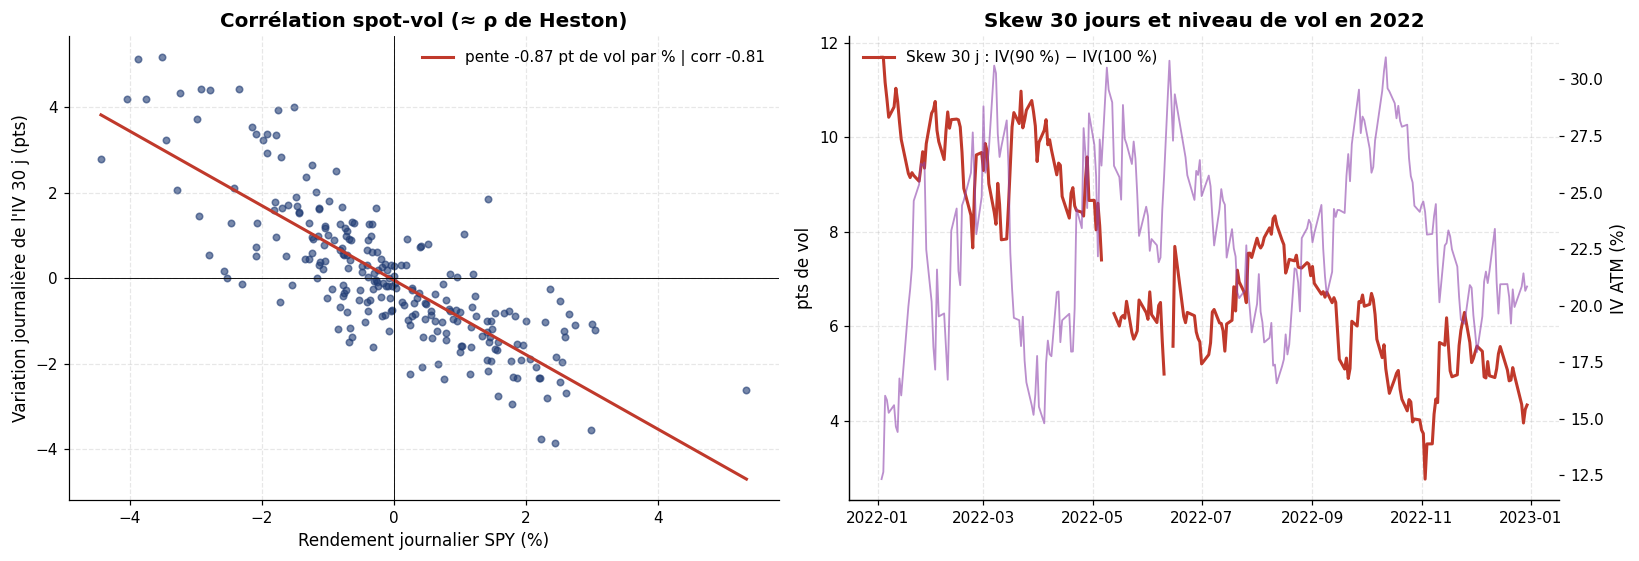

Bêta spot-vol : -0.87 pt d'IV par +1 % de SPY | corrélation rendements / ΔIV : -0.81
Corrélation skew / IV ATM : -0.45


In [6]:
d_iv = ts.iv30.diff() * 100
x, y = ts.ret * 100, d_iv
m = x.notna() & y.notna()
beta = np.polyfit(x[m], y[m], 1)
corr = np.corrcoef(x[m], y[m])[0, 1]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
axes[0].scatter(x[m], y[m], s=18, alpha=0.6, color=PALETTE["navy"])
xx = np.linspace(x.min(), x.max(), 10); axes[0].plot(xx, np.polyval(beta, xx), color=PALETTE["crimson"], lw=2, label=f"pente {beta[0]:.2f} pt de vol par % | corr {corr:.2f}")
axes[0].axhline(0, color="k", lw=0.6); axes[0].axvline(0, color="k", lw=0.6)
axes[0].set_xlabel("Rendement journalier SPY (%)"); axes[0].set_ylabel("Variation journalière de l'IV 30 j (pts)")
axes[0].set_title("Corrélation spot-vol (≈ ρ de Heston)"); axes[0].legend()
axes[1].plot(ts.index, ts.skew30 * 100, color=PALETTE["crimson"], lw=2, label="Skew 30 j : IV(90 %) − IV(100 %)")
axes[1].set_ylabel("pts de vol"); axes[1].legend(loc="upper left")
ax1b = axes[1].twinx(); ax1b.plot(ts.index, ts.iv30 * 100, color=PALETTE["purple"], lw=1.2, alpha=0.6, label="IV ATM 30 j"); ax1b.set_ylabel("IV ATM (%)"); ax1b.grid(False)
axes[1].set_title("Skew 30 jours et niveau de vol en 2022")
fig.tight_layout(); savefig(fig, "07_spot_vol_correlation_skew.png"); plt.show()
print(f"Bêta spot-vol : {beta[0]:.2f} pt d'IV par +1 % de SPY | corrélation rendements / ΔIV : {corr:.2f}")
print(f"Corrélation skew / IV ATM : {ts.skew30.corr(ts.iv30):.2f}")

La corrélation entre rendements et variations d'IV est fortement négative : c'est l'**effet de levier** (ou *spot-vol correlation*), la raison d'être du paramètre $\rho$ fortement négatif (−0,6 à −0,9) obtenu à la calibration de Heston. Côté skew, sa corrélation négative avec le niveau d'IV (−0,45) confirme l'observation du notebook 04 : le skew en points est le plus pentu quand la vol est basse.

## 3. Analyse par régime

Régimes définis par les **terciles de la vol réalisée passée 21 j** (information disponible à la date $t$, donc utilisable en temps réel) : *Vol basse*, *Vol moyenne*, *Vol haute*.

In [7]:
terc = ts.rv_back.quantile([1/3, 2/3]).values
print(f"Seuils des terciles de vol réalisée : {terc[0]:.1%} / {terc[1]:.1%}")
ts["regime"] = pd.cut(ts.rv_back, [0, terc[0], terc[1], 10], labels=["Vol basse", "Vol moyenne", "Vol haute"]).astype(object)
agg = ts.dropna(subset=["regime"]).groupby("regime").agg(
    jours=("iv30", "size"), IV30=("iv30", "mean"), RV_passée=("rv_back", "mean"), RV_future=("rv_fwd", "mean"),
    VRP=("vrp", "mean"), VRP_pos=("vrp", lambda s: (s.dropna() > 0).mean()), skew=("skew30", "mean"), drawdown=("drawdown", "mean"))
agg = agg.loc[["Vol basse", "Vol moyenne", "Vol haute"]]
tab = agg.copy()
for c in ["IV30", "RV_passée", "RV_future", "VRP", "skew", "drawdown", "VRP_pos"]:
    tab[c] = tab[c] * 100
tab.columns = ["Jours", "IV 30 j (%)", "RV passée (%)", "RV future (%)", "VRP moy. (pts)", "% jours VRP > 0", "Skew 90-100 (pts)", "Drawdown moy. (%)"]
save_table(tab.reset_index(names="Régime"), "07_regimes_table", floatfmt=".2f"); tab

Seuils des terciles de vol réalisée : 21.9% / 26.6%


,Jours,IV 30 j (%),RV passée (%),RV future (%),VRP moy. (pts),% jours VRP > 0,Skew 90-100 (pts),Drawdown moy. (%)
regime,,,,,,,,
Vol basse,76,20.6886,19.3097,25.7264,-5.0506,16.6667,7.8160,-12.6115
Vol moyenne,75,23.5203,24.3736,23.6573,0.2710,48.4848,7.2164,-14.7291
Vol haute,75,25.3854,29.7795,24.9146,0.6409,54.7945,5.7749,-18.3859


**Lecture du tableau.**
- En **vol basse** (vol réalisée passée < 21,9 %), l'IV (20,7 %) est au-dessus de la vol passée… mais **très en dessous** de la vol qui suit (25,7 %) : VRP de **−5,1 pts**, positive seulement 17 % des jours. Le calme de 2022 n'était qu'une accalmie entre deux vagues de baisse, et le marché l'a extrapolé.
- En **vol haute** (> 26,6 %), l'IV (25,4 %) est **inférieure** à la vol passée (29,8 %) : le marché anticipe le retour à la moyenne de la volatilité, à juste titre (vol future 24,9 %). La VRP redevient légèrement positive (+0,6 pt, positive 55 % des jours).
- Le **skew** est le plus pentu en vol basse (7,8 pts) et le plus plat en vol haute (5,8 pts), en cohérence avec le notebook 04.


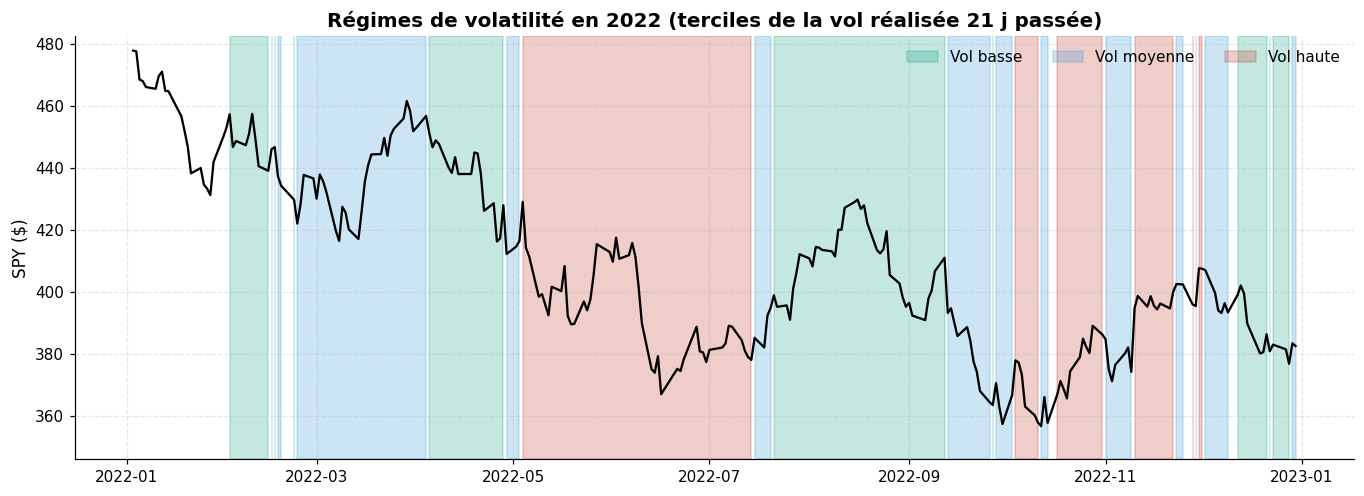

In [8]:
reg_col = {"Vol basse": PALETTE["teal"], "Vol moyenne": PALETTE["sky"], "Vol haute": PALETTE["crimson"]}
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ts.index, ts.spot, color="k", lw=1.5)
for g, c in reg_col.items():
    mask = ts.regime == g
    ax.fill_between(ts.index, ts.spot.min() * 0.97, ts.spot.max() * 1.01, where=mask, color=c, alpha=0.25, step="mid", label=g)
ax.set_ylim(ts.spot.min() * 0.97, ts.spot.max() * 1.01); ax.set_ylabel("SPY ($)"); ax.legend(ncol=3, loc="upper right")
ax.set_title("Régimes de volatilité en 2022 (terciles de la vol réalisée 21 j passée)")
savefig(fig, "07_regimes_timeline.png"); plt.show()

## Conclusions

1. **Implicite ≠ réalisée** : l'IV n'est pas une prévision non biaisée de la vol future. Sur 2022, la VRP moyenne est de **−1,4 pt** (IV 30 j moyenne 23,1 % vs vol réalisée future 24,5 %) et l'IV n'a dépassé la vol réalisée que **39 % des jours** : une année historiquement défavorable aux vendeurs de volatilité, alors qu'en temps normal la VRP des indices est positive de plusieurs points.
2. **L'IV reste le meilleur prédicteur disponible** : corrélation de 0,25 avec la vol future, contre ≈ 0 pour la vol passée.
3. **Le régime conditionne tout** : la VRP est très négative après les périodes calmes (le marché sous-estime les chocs) et légèrement positive après les pics (retour à la moyenne). Le skew en points est le plus pentu en vol basse, la structure par terme s'inverse en vol haute (notebook 04).
4. **Lien avec les modèles** : le bêta spot-vol (−0,87 pt d'IV par +1 % de SPY, corrélation −0,81) valide le $\rho$ fortement négatif de Heston ; les changements de régime rappellent qu'un jeu de paramètres calibré à une date ne décrit pas la dynamique future — d'où la nécessité de recalibrer et de gérer le **risque de vega**.
5. **Implication trading** : une stratégie de vente de vol delta-hedgée capte la VRP *en moyenne sur longue période*, mais son P&L est asymétrique (petits gains fréquents, grosses pertes quand la vol réalisée accélère). En 2022, un simple filtre de régime (ne vendre qu'après un pic de vol réalisée, pas en période calme) aurait évité l'essentiel des pertes — une piste naturelle de stratégie systématique à tester hors échantillon (sur 2020-2021 par exemple).
